In [8]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import functionsTP as myfunc

ACTIVE CONTOUR WITH BALLOON FORCE (CONTRACTION FOCUSED)
Testing 12 parameter combinations (focused on contraction):
----------------------------------------------------------------------
Alpha    Beta     Gamma    Kappa    Dice     Iterations  
----------------------------------------------------------------------
0.10     0.10     1.50     -0.30    0.8835   200         
0.10     0.10     1.50     -0.50    0.8835   200         
0.10     0.10     2.00     -0.30    0.8855   200         
0.10     0.10     2.00     -0.50    0.8855   200         
0.10     0.20     1.50     -0.30    0.8835   200         
0.10     0.20     1.50     -0.50    0.8835   200         
0.10     0.20     2.00     -0.30    0.8858   200         
0.10     0.20     2.00     -0.50    0.8858   200         
0.20     0.10     1.50     -0.30    0.8739   200         
0.20     0.10     1.50     -0.50    0.8739   200         
0.20     0.10     2.00     -0.30    0.8806   200         
0.20     0.10     2.00     -0.50    0.8806   2

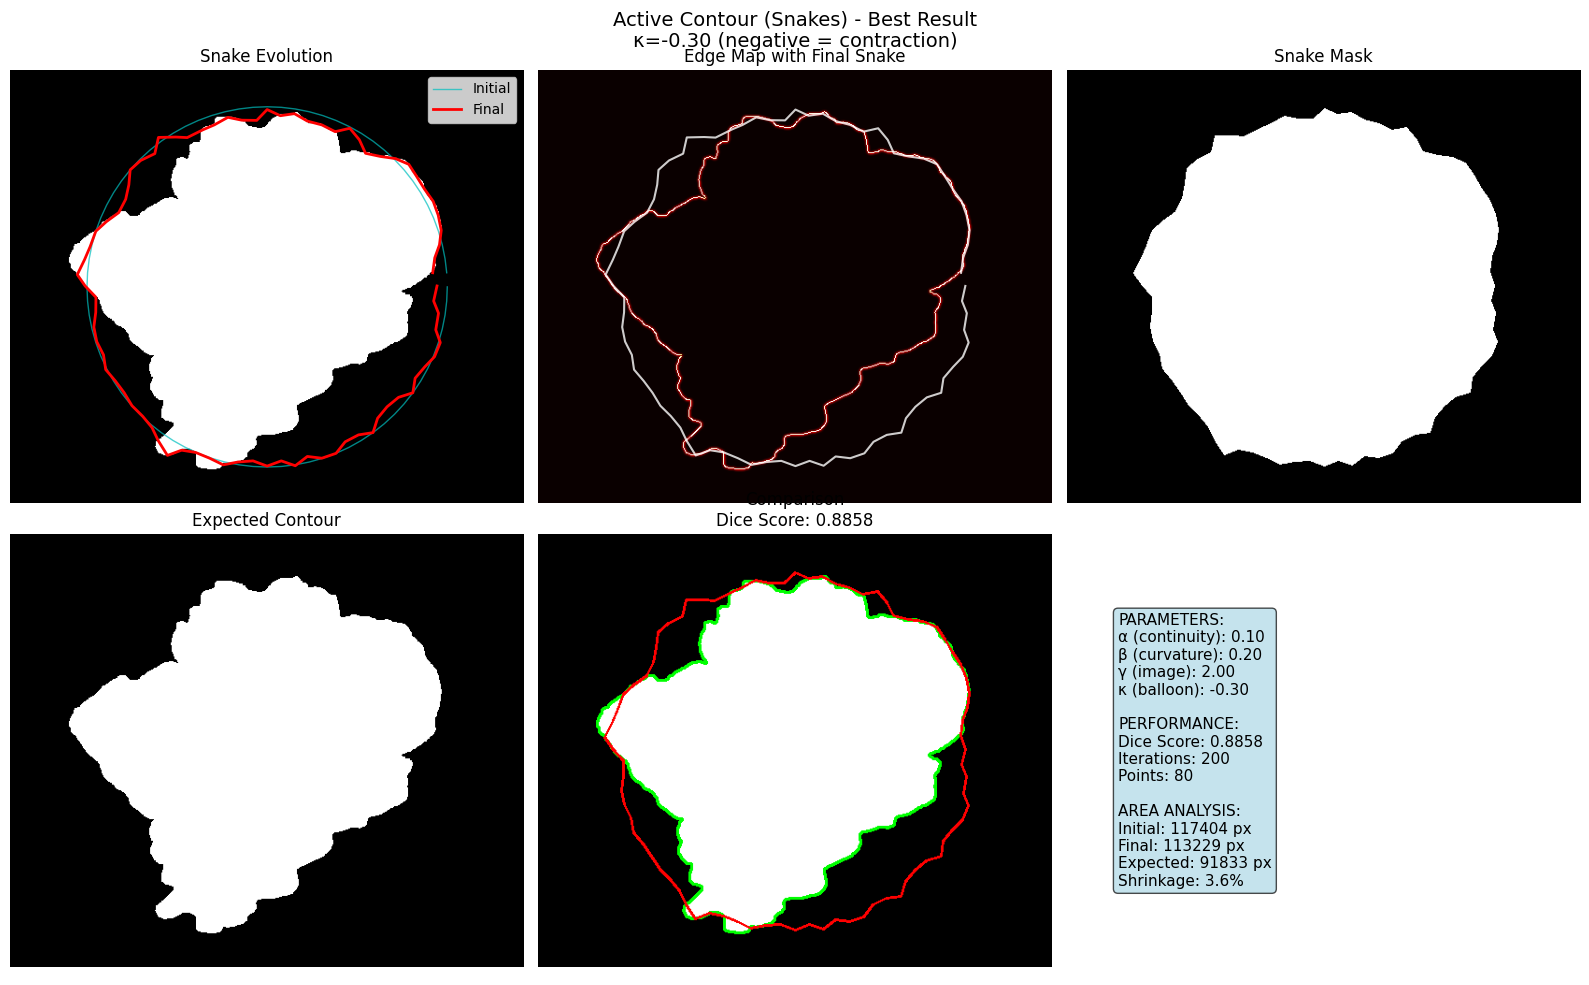

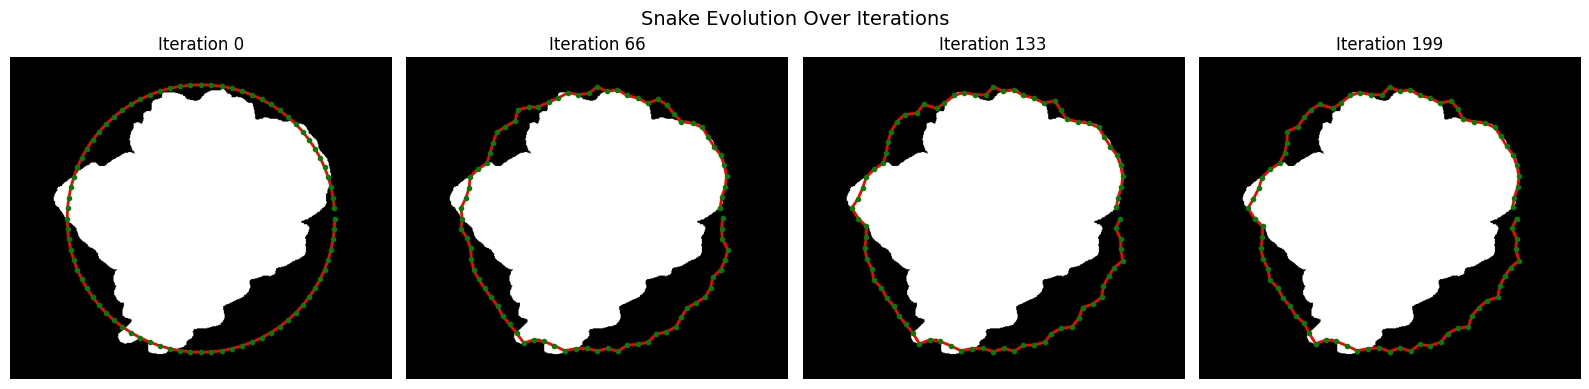

In [30]:
import cv2
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt
import itertools


def dice_score(mask1, mask2):
    """Compute Dice similarity coefficient between two binary masks"""
    intersection = np.logical_and(mask1, mask2).sum()
    if intersection == 0:
        return 0.0
    return (2. * intersection) / (mask1.sum() + mask2.sum())


def create_mask_from_contour(contour, shape):
    """Create a binary mask from a contour"""
    mask = np.zeros(shape, dtype=np.uint8)
    # Convert contour points to integer coordinates
    contour_int = contour.astype(np.int32)
    cv2.fillPoly(mask, [contour_int], 255)
    return mask


def compute_image_energy(image):
    """Compute edge map for image energy - multiple methods"""
    # Method 1: Gradient magnitude (original)
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    grad_mag = np.sqrt(sobel_x**2 + sobel_y**2)
    
    # Method 2: Canny edges (often better for snakes)
    edges = cv2.Canny(image, 50, 150)
    
    # Method 3: Gradient of Gaussian
    blurred = cv2.GaussianBlur(image, (5, 5), 1.5)
    sobel_x_blur = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y_blur = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    grad_mag_blur = np.sqrt(sobel_x_blur**2 + sobel_y_blur**2)
    
    # Combine methods
    edge_map = np.zeros_like(grad_mag, dtype=np.float32)
    
    # Normalize each component
    if grad_mag.max() > 0:
        grad_mag = grad_mag / grad_mag.max()
    if edges.max() > 0:
        edges_normalized = edges.astype(np.float32) / edges.max()
    else:
        edges_normalized = np.zeros_like(edges, dtype=np.float32)
    if grad_mag_blur.max() > 0:
        grad_mag_blur = grad_mag_blur / grad_mag_blur.max()
    
    # Combine: Canny edges are most reliable
    edge_map = 0.7 * edges_normalized + 0.2 * grad_mag_blur + 0.1 * grad_mag
    
    # Invert so edges have low energy
    edge_energy = 1 - edge_map
    
    return edge_energy, edge_map


def compute_normal_vectors(points):
    """Compute outward-pointing normal vectors for each point"""
    n = len(points)
    normals = np.zeros((n, 2))
    
    for i in range(n):
        # Get previous and next points
        prev = points[(i-1) % n]
        next_pt = points[(i+1) % n]
        
        # Compute tangent vector (average of forward and backward differences)
        tangent = np.array([next_pt[0] - prev[0], next_pt[1] - prev[1]])
        tangent_len = np.linalg.norm(tangent)
        if tangent_len > 0:
            tangent = tangent / tangent_len
        
        # Normal is perpendicular to tangent (rotate 90 degrees)
        normals[i] = np.array([-tangent[1], tangent[0]])
    
    return normals


def compute_curvature(points):
    """Compute curvature at each point of the snake"""
    n = len(points)
    curvatures = np.zeros(n)
    
    for i in range(n):
        # Get previous, current, and next points
        prev = points[(i-2) % n]
        curr = points[i]
        next_pt = points[(i+2) % n]
        
        # Compute first derivatives using central differences
        dx1 = curr[0] - prev[0]
        dy1 = curr[1] - prev[1]
        dx2 = next_pt[0] - curr[0]
        dy2 = next_pt[1] - curr[1]
        
        # Compute second derivatives
        ddx = dx2 - dx1
        ddy = dy2 - dy1
        
        # Compute curvature magnitude
        denom = (dx1**2 + dy1**2)**1.5
        if denom > 0:
            curvatures[i] = np.abs(dx1*ddy - dy1*ddx) / denom
        else:
            curvatures[i] = 0
    
    return curvatures


def find_local_maxima(curvatures, window=5):
    """Find local maxima in curvature"""
    n = len(curvatures)
    is_maxima = np.zeros(n, dtype=bool)
    
    for i in range(n):
        # Check neighborhood
        neighborhood = []
        for j in range(-window//2, window//2 + 1):
            idx = (i + j) % n
            neighborhood.append(curvatures[idx])
        
        # Check if current point is maximum in neighborhood
        if curvatures[i] == max(neighborhood) and curvatures[i] > 0:
            is_maxima[i] = True
    
    return is_maxima


def greedy_snake(image, initial_points, M=7, alpha=0.5, beta=0.5, gamma=1.0, 
                 kappa=0.3, curvature_threshold=0.1, max_iterations=200, 
                 min_movement_ratio=0.01, adaptive_weights=False):
    """
    Improved Greedy Active Contour (Snakes) algorithm with balloon force
    
    Parameters:
    -----------
    image : 2D numpy array
        Input grayscale image
    initial_points : Nx2 numpy array
        Initial snake points
    M : int
        Neighborhood size (MxM)
    alpha : float
        Continuity weight
    beta : float
        Curvature weight
    gamma : float
        Image energy weight
    kappa : float
        Balloon force weight (positive expands, negative contracts)
    curvature_threshold : float
        Threshold for corner detection
    max_iterations : int
        Maximum number of iterations
    min_movement_ratio : float
        Stop when less than this fraction of points move
    adaptive_weights : bool
        If True, reduce weights near convergence
    
    Returns:
    --------
    final_points : Nx2 numpy array
        Final snake points
    history : list
        History of snake points for each iteration
    """
    
    # Precompute image energy
    edge_energy, edge_map = compute_image_energy(image)
    
    # Initialize snake points
    points = initial_points.copy().astype(np.float32)
    n_points = len(points)
    
    # Compute initial average distance between points
    d = np.mean([np.linalg.norm(points[(i+1)%n_points] - points[i]) 
                 for i in range(n_points)])
    
    # Storage for iteration history
    history = [points.copy()]
    
    # Search offset coordinates for MxM neighborhood
    offset = M // 2
    search_offsets = []
    for dx in range(-offset, offset + 1):
        for dy in range(-offset, offset + 1):
            search_offsets.append((dx, dy))
    
    # For adaptive weights
    iteration_weights = np.ones(max_iterations)
    if adaptive_weights:
        # Gradually reduce internal forces, keep image force
        iteration_weights = np.linspace(1.0, 0.5, max_iterations)
    
    for iteration in range(max_iterations):
        new_points = points.copy()
        moved_count = 0
        
        # Compute normal vectors for balloon force
        normals = compute_normal_vectors(points)
        
        # Adaptive weight for this iteration
        w = iteration_weights[iteration] if iteration < len(iteration_weights) else 0.5
        
        # Step 1: For each point, search neighborhood for minimum energy
        for i in range(n_points):
            # Get neighboring points indices
            prev_idx = (i-1) % n_points
            next_idx = (i+1) % n_points
            
            prev_point = points[prev_idx]
            next_point = points[next_idx]
            curr_point = points[i]
            
            # Store best position and energy
            best_energy = float('inf')
            best_position = curr_point.copy()
            
            # Search in MxM neighborhood
            for dx, dy in search_offsets:
                candidate = np.array([curr_point[0] + dx, curr_point[1] + dy])
                
                # Ensure candidate is within image bounds
                if (0 <= candidate[0] < image.shape[1] and 
                    0 <= candidate[1] < image.shape[0]):
                    
                    # 1. Continuity energy
                    dist_to_prev = np.linalg.norm(candidate - prev_point)
                    dist_to_next = np.linalg.norm(candidate - next_point)
                    
                    # Target distance adapts based on current size
                    continuity_energy = w * alpha * ((dist_to_prev - d)**2 + (dist_to_next - d)**2)
                    
                    # 2. Curvature energy
                    # Get points for curvature calculation (skip immediate neighbors for stability)
                    prev_for_curv = points[(i-2) % n_points]
                    next_for_curv = points[(i+2) % n_points]
                    
                    dx1 = candidate[0] - prev_for_curv[0]
                    dy1 = candidate[1] - prev_for_curv[1]
                    dx2 = next_for_curv[0] - candidate[0]
                    dy2 = next_for_curv[1] - candidate[1]
                    
                    # Second derivatives
                    ddx = dx2 - dx1
                    ddy = dy2 - dy1
                    
                    # Curvature magnitude
                    denom = (dx1**2 + dy1**2)**1.5
                    if denom > 0:
                        curvature = np.abs(dx1*ddy - dy1*ddx) / denom
                        curvature_energy = w * beta * curvature**2
                    else:
                        curvature_energy = 0
                    
                    # 3. Image energy (edge strength)
                    x_int = int(candidate[0])
                    y_int = int(candidate[1])
                    if 0 <= x_int < image.shape[1] and 0 <= y_int < image.shape[0]:
                        # Use gamma directly (not weighted by w)
                        image_energy_val = gamma * edge_energy[y_int, x_int]
                    else:
                        image_energy_val = float('inf')
                    
                    # 4. Balloon force (inflation/deflation)
                    # kappa > 0 expands, kappa < 0 contracts
                    normal = normals[i]
                    balloon_force = -kappa  # Negative because we want to minimize energy
                    
                    # 5. Gradient of image energy (additional pull toward edges)
                    if x_int > 0 and x_int < image.shape[1]-1 and y_int > 0 and y_int < image.shape[0]-1:
                        # Compute gradient of edge map
                        grad_x = edge_map[y_int, x_int+1] - edge_map[y_int, x_int-1]
                        grad_y = edge_map[y_int+1, x_int] - edge_map[y_int-1, x_int]
                        gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)
                        gradient_force = -0.2 * gradient_magnitude  # Pull toward edges
                    else:
                        gradient_force = 0
                    
                    # Total energy (image energy is not weighted by w)
                    total_energy = (continuity_energy + curvature_energy + 
                                   image_energy_val + balloon_force + gradient_force)
                    
                    if total_energy < best_energy:
                        best_energy = total_energy
                        best_position = candidate
            
            # Update point if it moved
            if not np.array_equal(best_position, curr_point):
                moved_count += 1
                new_points[i] = best_position
        
        # Step 2: Compute curvature and detect corners
        curvatures = compute_curvature(new_points)
        local_maxima = find_local_maxima(curvatures, window=5)
        
        # Mark corners
        corners = local_maxima & (curvatures > curvature_threshold)
        
        # Step 3: Update average distance d
        # Adaptive distance: if snake should shrink, reduce target distance
        distances = []
        for i in range(n_points):
            if not corners[i]:
                next_i = (i+1) % n_points
                if not corners[next_i]:
                    dist = np.linalg.norm(new_points[next_i] - new_points[i])
                    distances.append(dist)
        
        if distances:
            current_avg_dist = np.mean(distances)
            # If kappa < 0 (contracting), gradually reduce target distance
            if kappa < -0.1:
                d = 0.95 * d + 0.05 * current_avg_dist
            else:
                d = current_avg_dist
        
        # Update points
        points = new_points.copy()
        history.append(points.copy())
        
        # Check stopping criterion
        movement_ratio = moved_count / n_points
        if movement_ratio < min_movement_ratio and iteration > 20:
            break
    
    return points, history, iteration + 1


def initialize_snake_from_image(image_shape, center=None, radius=None, n_points=80):
    """Initialize a circular snake around the image center or given center"""
    if center is None:
        center = (image_shape[1] // 2, image_shape[0] // 2)
    
    if radius is None:
        radius = min(image_shape) // 2.4  # Start smaller
    
    # Create circular contour
    angles = np.linspace(0, 2*np.pi, n_points, endpoint=False)
    points = np.zeros((n_points, 2), dtype=np.float32)
    
    for i, angle in enumerate(angles):
        points[i, 0] = center[0] + radius * np.cos(angle)
        points[i, 1] = center[1] + radius * np.sin(angle)
    
    return points


def test_parameter_combinations(img_gray, initial_points, expected_mask):
    """Test different parameter combinations and return the best result"""
    
    # Define parameter combinations to test
    # Focus on combinations that help SHRINK the snake
    alphas = [0.1, 0.2, 0.3]  # Continuity weight (lower for more flexibility)
    betas = [0.1, 0.2, 0.3]   # Curvature weight (lower for more flexibility)
    gammas = [1.5, 2.0]       # Image energy weight (higher to pull toward edges)
    kappas = [-0.3, -0.5]     # Balloon force (NEGATIVE to contract)
    
    # Create combinations (3*3*2*2 = 36, we'll take 12 diverse ones)
    param_combinations = []
    for alpha in alphas[:2]:  # Take first 2 alphas
        for beta in betas[:2]:  # Take first 2 betas
            for gamma in gammas:
                for kappa in kappas:
                    param_combinations.append((alpha, beta, gamma, kappa))
                    if len(param_combinations) >= 12:
                        break
            if len(param_combinations) >= 12:
                break
        if len(param_combinations) >= 12:
            break
    
    # Ensure we have exactly 12
    param_combinations = param_combinations[:12]
    
    best_dice = -1
    best_params = None
    best_result = None
    results = []
    
    print("Testing 12 parameter combinations (focused on contraction):")
    print("-" * 70)
    print(f"{'Alpha':<8} {'Beta':<8} {'Gamma':<8} {'Kappa':<8} {'Dice':<8} {'Iterations':<12}")
    print("-" * 70)
    
    for idx, (alpha, beta, gamma, kappa) in enumerate(param_combinations):
        # Run snake algorithm with current parameters
        final_points, history, iterations = greedy_snake(
            img_gray, 
            initial_points,
            M=11,  # Larger neighborhood
            alpha=alpha,
            beta=beta,
            gamma=gamma,
            kappa=kappa,  # Negative to contract
            curvature_threshold=0.05,
            max_iterations=200,
            min_movement_ratio=0.005,  # More sensitive stopping
            adaptive_weights=True
        )
        
        # Create mask from final snake contour
        snake_mask = create_mask_from_contour(final_points, img_gray.shape)
        
        # Compute Dice score
        dice = dice_score(snake_mask > 0, expected_mask > 0)
        
        # Store results
        results.append({
            'alpha': alpha,
            'beta': beta,
            'gamma': gamma,
            'kappa': kappa,
            'dice': dice,
            'iterations': iterations,
            'final_points': final_points,
            'snake_mask': snake_mask,
            'history': history
        })
        
        # Print current result
        print(f"{alpha:<8.2f} {beta:<8.2f} {gamma:<8.2f} {kappa:<8.2f} "
              f"{dice:<8.4f} {iterations:<12}")
        
        # Update best result
        if dice > best_dice:
            best_dice = dice
            best_params = (alpha, beta, gamma, kappa)
            best_result = results[-1]
    
    print("-" * 70)
    print(f"Best parameters: alpha={best_params[0]:.2f}, beta={best_params[1]:.2f}, "
          f"gamma={best_params[2]:.2f}, kappa={best_params[3]:.2f}")
    print(f"Best Dice score: {best_dice:.4f}")
    
    return best_result, results


def plot_best_result(img_gray, best_result, expected_mask, initial_points):
    """Create comprehensive plot for the best result"""
    
    final_points = best_result['final_points']
    snake_mask = best_result['snake_mask']
    alpha = best_result['alpha']
    beta = best_result['beta']
    gamma = best_result['gamma']
    kappa = best_result['kappa']
    dice = best_result['dice']
    iterations = best_result['iterations']
    history = best_result['history']
    
    # Create visualization
    fig = plt.figure(figsize=(16, 10))
    
    # 1. Original image with initial and final snake
    ax1 = plt.subplot(2, 3, 1)
    ax1.imshow(img_gray, cmap='gray')
    ax1.plot(initial_points[:, 0], initial_points[:, 1], 'c-', linewidth=1, alpha=0.7, label='Initial')
    ax1.plot(final_points[:, 0], final_points[:, 1], 'r-', linewidth=2, label='Final')
    ax1.set_title('Snake Evolution')
    ax1.legend(loc='upper right')
    ax1.axis('off')
    
    # 2. Edge map
    _, edge_map = compute_image_energy(img_gray)
    ax2 = plt.subplot(2, 3, 2)
    ax2.imshow(edge_map, cmap='hot')
    ax2.plot(final_points[:, 0], final_points[:, 1], 'w-', linewidth=1.5, alpha=0.8)
    ax2.set_title('Edge Map with Final Snake')
    ax2.axis('off')
    
    # 3. Snake mask
    ax3 = plt.subplot(2, 3, 3)
    ax3.imshow(snake_mask, cmap='gray')
    ax3.set_title('Snake Mask')
    ax3.axis('off')
    
    # 4. Expected contour
    ax4 = plt.subplot(2, 3, 4)
    ax4.imshow(expected_mask, cmap='gray')
    ax4.set_title('Expected Contour')
    ax4.axis('off')
    
    # 5. Overlay comparison
    overlay = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
    # Draw expected contour in green
    contours_expected, _ = cv2.findContours(expected_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours_expected:
        cv2.drawContours(overlay, contours_expected, -1, (0, 255, 0), 2)
    # Draw snake contour in red
    snake_contour = final_points.astype(np.int32).reshape((-1, 1, 2))
    cv2.polylines(overlay, [snake_contour], True, (255, 0, 0), 2)
    ax5 = plt.subplot(2, 3, 5)
    ax5.imshow(overlay)
    ax5.set_title(f'Comparison\nDice Score: {dice:.4f}')
    ax5.axis('off')
    
    # 6. Parameter summary and evolution
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')
    
    # Calculate area change
    initial_mask = create_mask_from_contour(initial_points, img_gray.shape)
    initial_area = np.sum(initial_mask > 0)
    final_area = np.sum(snake_mask > 0)
    expected_area = np.sum(expected_mask > 0)
    
    param_text = f"PARAMETERS:\n"
    param_text += f"α (continuity): {alpha:.2f}\n"
    param_text += f"β (curvature): {beta:.2f}\n"
    param_text += f"γ (image): {gamma:.2f}\n"
    param_text += f"κ (balloon): {kappa:.2f}\n\n"
    
    param_text += f"PERFORMANCE:\n"
    param_text += f"Dice Score: {dice:.4f}\n"
    param_text += f"Iterations: {iterations}\n"
    param_text += f"Points: {len(final_points)}\n\n"
    
    param_text += f"AREA ANALYSIS:\n"
    param_text += f"Initial: {initial_area:.0f} px\n"
    param_text += f"Final: {final_area:.0f} px\n"
    param_text += f"Expected: {expected_area:.0f} px\n"
    param_text += f"Shrinkage: {100*(initial_area-final_area)/initial_area:.1f}%"
    
    ax6.text(0.1, 0.5, param_text, transform=ax6.transAxes,
             fontsize=11, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    
    plt.suptitle(f'Active Contour (Snakes) - Best Result\n'
                 f'κ={kappa:.2f} (negative = contraction)', fontsize=14)
    plt.tight_layout()
    
    # Additional figure: Evolution of the snake
    fig2, axs = plt.subplots(1, 4, figsize=(16, 4))
    iteration_indices = [0, iterations//3, 2*iterations//3, iterations-1]
    
    for idx, ax in enumerate(axs):
        iter_idx = min(iteration_indices[idx], len(history)-1)
        points_at_iter = history[iter_idx]
        
        ax.imshow(img_gray, cmap='gray')
        ax.plot(points_at_iter[:, 0], points_at_iter[:, 1], 'r-', linewidth=2)
        ax.plot(points_at_iter[:, 0], points_at_iter[:, 1], 'go', markersize=3)
        ax.set_title(f'Iteration {iter_idx}')
        ax.axis('off')
    
    plt.suptitle('Snake Evolution Over Iterations', fontsize=14)
    plt.tight_layout()
    
    return fig, fig2


def main():
    # Load images
    # image_orig = r'images\skin-waterloo\SSM33_orig.jpg'
    image_orig = r'images\skin-waterloo\SSM33_contour.png'
    image_contour = r'images\skin-waterloo\SSM33_contour.png'
    
    # Load the original image
    img_bgr = cv2.imread(image_orig)
    if img_bgr is None:
        # Try without the path prefix if file not found
        image_orig = 'SSM33_orig.jpg'
        img_bgr = cv2.imread(image_orig)
        if img_bgr is None:
            # Create a synthetic image for testing
            print("Creating synthetic image for testing...")
            img_bgr = np.zeros((400, 400, 3), dtype=np.uint8)
            cv2.circle(img_bgr, (200, 200), 150, (255, 255, 255), -1)
            cv2.circle(img_bgr, (200, 200), 100, (0, 0, 0), -1)
    
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # Load or create expected contour
    contour_img = cv2.imread(image_contour, cv2.IMREAD_GRAYSCALE)
    if contour_img is None:
        # Create a synthetic contour for testing
        print("Creating synthetic contour for testing...")
        contour_img = np.zeros_like(img_gray)
        center = (img_gray.shape[1] // 2, img_gray.shape[0] // 2)
        radius = min(img_gray.shape) // 4  # Smaller than initial snake
        cv2.circle(contour_img, center, radius, 255, -1)
    
    # Create expected mask
    if contour_img.max() > 0:
        _, expected_mask = cv2.threshold(contour_img, 127, 255, cv2.THRESH_BINARY)
    else:
        expected_mask = np.zeros_like(img_gray)
    
    # Initialize snake points (start with a larger circle)
    initial_points = initialize_snake_from_image(img_gray.shape, n_points=80)
    
    # Test different parameter combinations
    print("=" * 70)
    print("ACTIVE CONTOUR WITH BALLOON FORCE (CONTRACTION FOCUSED)")
    print("=" * 70)
    
    best_result, all_results = test_parameter_combinations(img_gray, initial_points, expected_mask)
    
    # Plot the best result
    print("\n" + "=" * 70)
    print("VISUALIZING BEST RESULT")
    print("=" * 70)
    
    fig1, fig2 = plot_best_result(img_gray, best_result, expected_mask, initial_points)
    
    # Print detailed summary
    print("\n" + "=" * 70)
    print("FINAL SUMMARY")
    print("=" * 70)
    print(f"Best parameters found:")
    print(f"  Alpha (continuity weight): {best_result['alpha']:.2f}")
    print(f"  Beta (curvature weight): {best_result['beta']:.2f}")
    print(f"  Gamma (image energy weight): {best_result['gamma']:.2f}")
    print(f"  Kappa (balloon force): {best_result['kappa']:.2f} (negative = contracts)")
    
    initial_mask = create_mask_from_contour(initial_points, img_gray.shape)
    initial_area = np.sum(initial_mask > 0)
    final_area = np.sum(best_result['snake_mask'] > 0)
    expected_area = np.sum(expected_mask > 0)
    
    print(f"\nArea analysis:")
    print(f"  Initial snake area: {initial_area:.0f} pixels")
    print(f"  Final snake area: {final_area:.0f} pixels")
    print(f"  Expected area: {expected_area:.0f} pixels")
    print(f"  Area reduction: {100*(initial_area-final_area)/initial_area:.1f}%")
    print(f"  Area error: {100*abs(final_area-expected_area)/expected_area:.1f}%")
    
    print(f"\nPerformance metrics:")
    print(f"  Dice Score: {best_result['dice']:.4f}")
    print(f"  Iterations: {best_result['iterations']}")
    
    # Show all results sorted by Dice score
    print(f"\nAll results sorted by Dice score:")
    print("-" * 70)
    print(f"{'Rank':<6} {'Alpha':<8} {'Beta':<8} {'Gamma':<8} {'Kappa':<8} {'Dice':<8} {'Iterations':<12}")
    print("-" * 70)
    
    sorted_results = sorted(all_results, key=lambda x: x['dice'], reverse=True)
    for rank, result in enumerate(sorted_results, 1):
        print(f"{rank:<6} {result['alpha']:<8.2f} {result['beta']:<8.2f} "
              f"{result['gamma']:<8.2f} {result['kappa']:<8.2f} "
              f"{result['dice']:<8.4f} {result['iterations']:<12}")
    
    plt.show()
    
    return best_result, all_results


if __name__ == "__main__":
    best_result, all_results = main()

Running greedy snake algorithm...
Iteration 0: 23/100 points moved
Iteration 10: 70/100 points moved
Iteration 20: 67/100 points moved
Iteration 30: 67/100 points moved
Iteration 40: 67/100 points moved
Iteration 50: 67/100 points moved
Iteration 60: 67/100 points moved
Iteration 70: 67/100 points moved
Iteration 80: 67/100 points moved
Iteration 90: 67/100 points moved
Iteration 100: 67/100 points moved
Iteration 110: 67/100 points moved
Iteration 120: 67/100 points moved
Iteration 130: 67/100 points moved
Iteration 140: 67/100 points moved
Iteration 150: 67/100 points moved
Iteration 160: 67/100 points moved
Iteration 170: 67/100 points moved
Iteration 180: 67/100 points moved
Iteration 190: 67/100 points moved
Iteration 200: 67/100 points moved
Iteration 210: 67/100 points moved
Iteration 220: 67/100 points moved
Iteration 230: 67/100 points moved
Iteration 240: 67/100 points moved
Iteration 250: 67/100 points moved
Iteration 260: 67/100 points moved
Iteration 270: 67/100 points mov

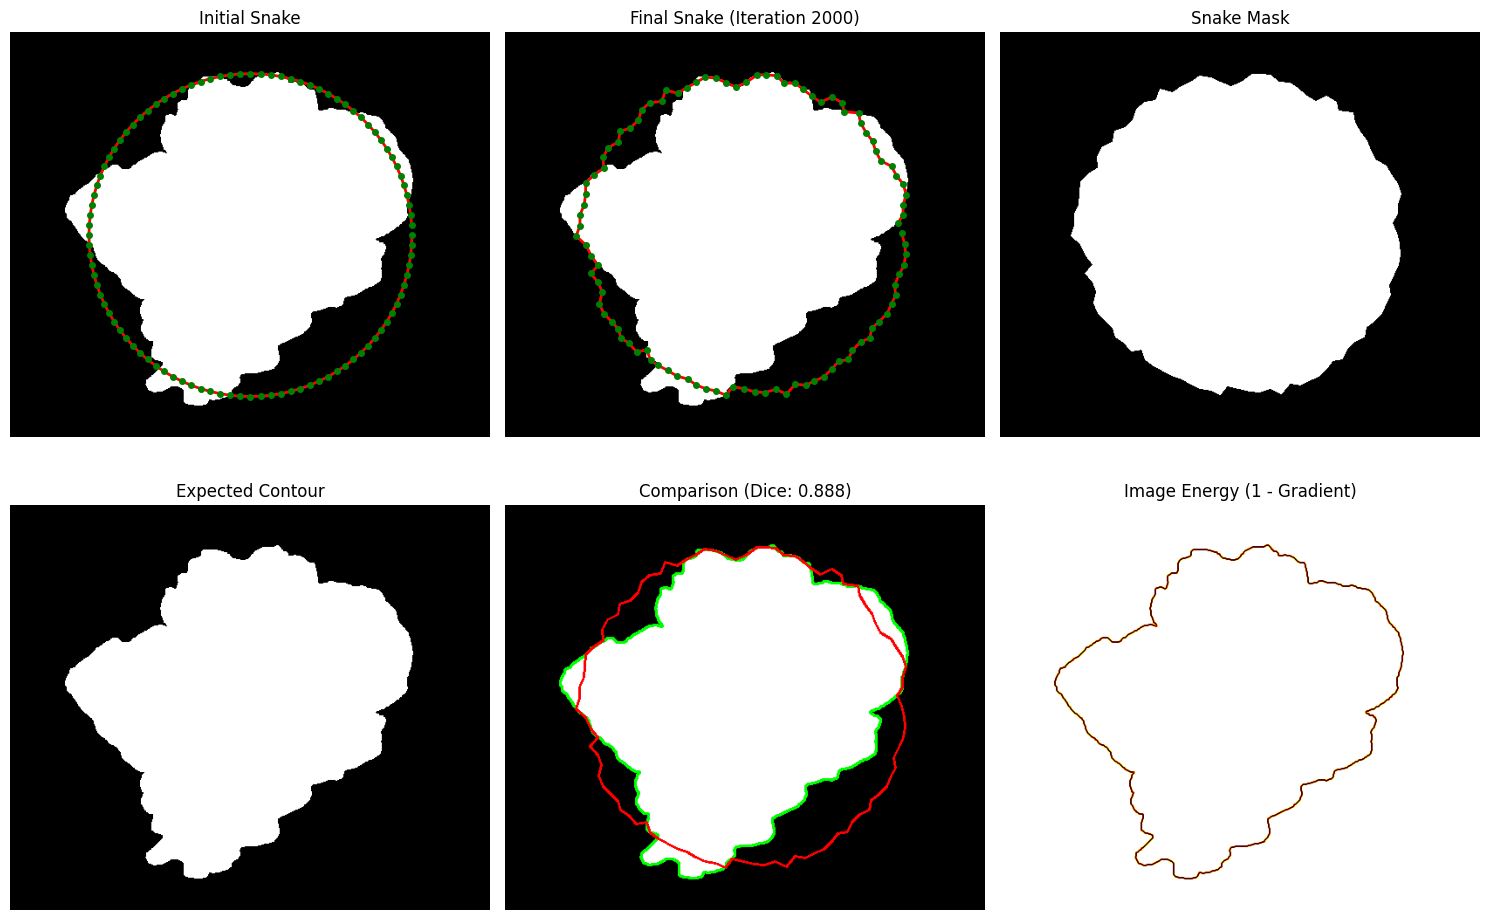


Algorithm Summary:
Initial points: 100
Final points: 100
Total iterations: 2000
Dice Score: 0.8879


In [24]:
import cv2
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt


def dice_score(mask1, mask2):
    """Compute Dice similarity coefficient between two binary masks"""
    intersection = np.logical_and(mask1, mask2).sum()
    if intersection == 0:
        return 0.0
    return (2. * intersection) / (mask1.sum() + mask2.sum())


def create_mask_from_contour(contour, shape):
    """Create a binary mask from a contour"""
    mask = np.zeros(shape, dtype=np.uint8)
    # Convert contour points to integer coordinates
    contour_int = contour.astype(np.int32)
    cv2.fillPoly(mask, [contour_int], 255)
    return mask


def compute_image_energy(image):
    """Compute gradient magnitude for image energy"""
    # Compute gradients
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    
    # Gradient magnitude
    grad_mag = np.sqrt(sobel_x**2 + sobel_y**2)
    
    # Normalize to 0-1 range
    if grad_mag.max() > 0:
        grad_mag = grad_mag / grad_mag.max()
    
    # Invert so edges have low energy (we want to minimize energy)
    edge_energy = 1 - grad_mag
    
    return edge_energy


def compute_curvature(points):
    """Compute curvature at each point of the snake"""
    n = len(points)
    curvatures = np.zeros(n)
    
    for i in range(n):
        # Get previous, current, and next points
        prev = points[(i-1) % n]
        curr = points[i]
        next_pt = points[(i+1) % n]
        
        # Compute first derivatives
        dx1 = curr[0] - prev[0]
        dy1 = curr[1] - prev[1]
        dx2 = next_pt[0] - curr[0]
        dy2 = next_pt[1] - curr[1]
        
        # Compute second derivatives
        ddx = dx2 - dx1
        ddy = dy2 - dy1
        
        # Compute curvature magnitude
        denom = (dx1**2 + dy1**2)**1.5
        if denom > 0:
            curvatures[i] = np.abs(dx1*ddy - dy1*ddx) / denom
        else:
            curvatures[i] = 0
    
    return curvatures


def find_local_maxima(curvatures, window=3):
    """Find local maxima in curvature"""
    n = len(curvatures)
    is_maxima = np.zeros(n, dtype=bool)
    
    for i in range(n):
        # Check neighborhood
        neighborhood = []
        for j in range(-window//2, window//2 + 1):
            idx = (i + j) % n
            neighborhood.append(curvatures[idx])
        
        # Check if current point is maximum in neighborhood
        if curvatures[i] == max(neighborhood):
            is_maxima[i] = True
    
    return is_maxima


def greedy_snake(image, initial_points, M=7, alpha=0.5, beta=0.5, gamma=1.0, 
                 curvature_threshold=0.1, max_iterations=100, min_movement_ratio=0.01):
    """
    Greedy Active Contour (Snakes) algorithm
    
    Parameters:
    -----------
    image : 2D numpy array
        Input grayscale image
    initial_points : Nx2 numpy array
        Initial snake points
    M : int
        Neighborhood size (MxM)
    alpha : float
        Continuity weight
    beta : float
        Curvature weight
    gamma : float
        Image energy weight
    curvature_threshold : float
        Threshold for corner detection
    max_iterations : int
        Maximum number of iterations
    min_movement_ratio : float
        Stop when less than this fraction of points move
    
    Returns:
    --------
    final_points : Nx2 numpy array
        Final snake points
    history : list
        History of snake points for each iteration
    """
    
    # Precompute image energy (inverted gradient magnitude)
    edge_energy = compute_image_energy(image)
    
    # Initialize snake points
    points = initial_points.copy().astype(np.float32)
    n_points = len(points)
    
    # Compute initial average distance between points
    d = np.mean([np.linalg.norm(points[(i+1)%n_points] - points[i]) 
                 for i in range(n_points)])
    
    # Storage for iteration history
    history = [points.copy()]
    
    # Search offset coordinates for MxM neighborhood
    offset = M // 2
    search_offsets = []
    for dx in range(-offset, offset + 1):
        for dy in range(-offset, offset + 1):
            search_offsets.append((dx, dy))
    
    for iteration in range(max_iterations):
        new_points = points.copy()
        moved_count = 0
        
        # Step 1: For each point, search neighborhood for minimum energy
        for i in range(n_points):
            # Get neighboring points indices
            prev_idx = (i-1) % n_points
            next_idx = (i+1) % n_points
            
            prev_point = points[prev_idx]
            next_point = points[next_idx]
            curr_point = points[i]
            
            # Store best position and energy
            best_energy = float('inf')
            best_position = curr_point.copy()
            
            # Search in MxM neighborhood
            for dx, dy in search_offsets:
                candidate = np.array([curr_point[0] + dx, curr_point[1] + dy])
                
                # Ensure candidate is within image bounds
                if (0 <= candidate[0] < image.shape[1] and 
                    0 <= candidate[1] < image.shape[0]):
                    
                    # Compute continuity energy (distance to neighbors)
                    dist_to_prev = np.linalg.norm(candidate - prev_point)
                    dist_to_next = np.linalg.norm(candidate - next_point)
                    
                    # Continuity term: minimize deviation from average distance
                    continuity_energy = alpha * ((dist_to_prev - d)**2 + (dist_to_next - d)**2)
                    
                    # Compute curvature energy (using finite differences)
                    # For candidate position, estimate curvature with neighbors
                    dx1 = candidate[0] - prev_point[0]
                    dy1 = candidate[1] - prev_point[1]
                    dx2 = next_point[0] - candidate[0]
                    dy2 = next_point[1] - candidate[1]
                    
                    # Second derivatives
                    ddx = dx2 - dx1
                    ddy = dy2 - dy1
                    
                    # Curvature magnitude
                    denom = (dx1**2 + dy1**2)**1.5
                    if denom > 0:
                        curvature = np.abs(dx1*ddy - dy1*ddx) / denom
                    else:
                        curvature = 0
                    
                    curvature_energy = beta * curvature**2
                    
                    # Image energy (edge strength - we want low values at edges)
                    # Note: edge_energy is 1-gradient_magnitude, so edges have low values
                    x_int = int(candidate[0])
                    y_int = int(candidate[1])
                    if 0 <= x_int < image.shape[1] and 0 <= y_int < image.shape[0]:
                        image_energy = gamma * edge_energy[y_int, x_int]
                    else:
                        image_energy = float('inf')
                    
                    # Total energy
                    total_energy = continuity_energy + curvature_energy + image_energy
                    
                    if total_energy < best_energy:
                        best_energy = total_energy
                        best_position = candidate
            
            # Update point if it moved
            if not np.array_equal(best_position, curr_point):
                moved_count += 1
                new_points[i] = best_position
        
        # Step 2: Compute curvature and detect corners
        curvatures = compute_curvature(new_points)
        local_maxima = find_local_maxima(curvatures, window=5)
        
        # Set β to zero at corners (curvature local maxima exceeding threshold)
        # In practice, we could adjust weights, but per algorithm description:
        # We simply mark these points as corners
        corners = local_maxima & (curvatures > curvature_threshold)
        
        # Step 3: Update average distance d
        # Compute distances between consecutive points
        distances = []
        for i in range(n_points):
            if not corners[i]:  # Don't include corners in distance calculation
                next_i = (i+1) % n_points
                if not corners[next_i]:  # Also check next point is not a corner
                    dist = np.linalg.norm(new_points[next_i] - new_points[i])
                    distances.append(dist)
        
        if distances:  # Update d if we have valid distances
            d = np.mean(distances)
        
        # Update points
        points = new_points.copy()
        history.append(points.copy())
        
        # Check stopping criterion
        movement_ratio = moved_count / n_points
        if movement_ratio < min_movement_ratio:
            print(f"Stopping at iteration {iteration}: {movement_ratio:.4f} points moved")
            break
        
        if iteration % 10 == 0:
            print(f"Iteration {iteration}: {moved_count}/{n_points} points moved")
    
    return points, history


def initialize_snake_from_image(image_shape, center=None, radius=None, n_points=50):
    """Initialize a circular snake around the image center or given center"""
    if center is None:
        center = (image_shape[1] // 2, image_shape[0] // 2)
    
    if radius is None:
        radius = min(image_shape) // 2.5
    
    # Create circular contour
    angles = np.linspace(0, 2*np.pi, n_points, endpoint=False)
    points = np.zeros((n_points, 2), dtype=np.float32)
    
    for i, angle in enumerate(angles):
        points[i, 0] = center[0] + radius * np.cos(angle)
        points[i, 1] = center[1] + radius * np.sin(angle)
    
    return points


def main():
    # Load images
    # image_orig = r'images\skin-waterloo\SSM33_orig.jpg'
    image_orig = r'images\skin-waterloo\SSM33_contour.png'
    image_contour = r'images\skin-waterloo\SSM33_contour.png'
    
    # Load the original image
    img_bgr = cv2.imread(image_orig)
    if img_bgr is None:
        raise FileNotFoundError(f"File not found or cannot be read: {image_orig}")
    
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # Load the expected contour image
    contour_img = cv2.imread(image_contour, cv2.IMREAD_GRAYSCALE)
    if contour_img is None:
        # If contour image doesn't exist, we'll just run the snake algorithm
        contour_img = np.zeros_like(img_gray)
        print("Warning: Contour image not found, will only run snake algorithm")
    
    # Initialize snake points (circular contour around center)
    initial_points = initialize_snake_from_image(img_gray.shape, n_points=100)
    
    # Run greedy snake algorithm
    print("Running greedy snake algorithm...")
    final_points, history = greedy_snake(
        img_gray, 
        initial_points,
        M=9,  # 9x9 neighborhood
        alpha=0.3,  # Continuity weight
        beta=0.3,   # Curvature weight  
        gamma=50.0,  # Image energy weight
        curvature_threshold=0.05,
        max_iterations=2000,
        min_movement_ratio=0.02
    )
    
    # Create mask from final snake contour
    snake_mask = create_mask_from_contour(final_points, img_gray.shape)
    
    # Create mask from expected contour (threshold if needed)
    if contour_img.max() > 0:
        # Threshold to get binary mask
        _, expected_mask = cv2.threshold(contour_img, 127, 255, cv2.THRESH_BINARY)
    else:
        expected_mask = np.zeros_like(img_gray)
    
    # Compute Dice score
    dice = dice_score(snake_mask > 0, expected_mask > 0)
    print(f"\nDice Score: {dice:.4f}")
    
    # Visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Original image with initial snake
    axes[0, 0].imshow(img_gray, cmap='gray')
    axes[0, 0].plot(initial_points[:, 0], initial_points[:, 1], 'r-', linewidth=2)
    axes[0, 0].plot(initial_points[:, 0], initial_points[:, 1], 'go', markersize=4)
    axes[0, 0].set_title('Initial Snake')
    axes[0, 0].axis('off')
    
    # Original image with final snake
    axes[0, 1].imshow(img_gray, cmap='gray')
    axes[0, 1].plot(final_points[:, 0], final_points[:, 1], 'r-', linewidth=2)
    axes[0, 1].plot(final_points[:, 0], final_points[:, 1], 'go', markersize=4)
    axes[0, 1].set_title(f'Final Snake (Iteration {len(history)-1})')
    axes[0, 1].axis('off')
    
    # Snake mask
    axes[0, 2].imshow(snake_mask, cmap='gray')
    axes[0, 2].set_title('Snake Mask')
    axes[0, 2].axis('off')
    
    # Expected contour
    axes[1, 0].imshow(expected_mask, cmap='gray')
    axes[1, 0].set_title('Expected Contour')
    axes[1, 0].axis('off')
    
    # Overlay comparison
    overlay = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
    # Draw expected contour in green
    contours_expected, _ = cv2.findContours(expected_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours_expected, -1, (0, 255, 0), 2)
    # Draw snake contour in red
    snake_contour = final_points.astype(np.int32).reshape((-1, 1, 2))
    cv2.polylines(overlay, [snake_contour], True, (255, 0, 0), 2)
    axes[1, 1].imshow(overlay)
    axes[1, 1].set_title(f'Comparison (Dice: {dice:.3f})')
    axes[1, 1].axis('off')
    
    # Evolution animation placeholder or energy visualization
    edge_energy = compute_image_energy(img_gray)
    axes[1, 2].imshow(edge_energy, cmap='hot')
    axes[1, 2].set_title('Image Energy (1 - Gradient)')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\nAlgorithm Summary:")
    print(f"Initial points: {len(initial_points)}")
    print(f"Final points: {len(final_points)}")
    print(f"Total iterations: {len(history)-1}")
    print(f"Dice Score: {dice:.4f}")
    
    return final_points, snake_mask, expected_mask, dice


if __name__ == "__main__":
    final_points, snake_mask, expected_mask, dice = main()

ACTIVE CONTOUR (SNAKES) PARAMETER OPTIMIZATION
Testing 12 parameter combinations:
------------------------------------------------------------
Alpha    Beta     Gamma    Dice     Iterations  
------------------------------------------------------------
0.10     0.10     0.80     0.8846   400         
0.10     0.10     1.20     0.8862   400         
0.10     0.30     0.80     0.8839   400         
0.10     0.30     1.20     0.8862   400         
0.10     0.50     0.80     0.8848   400         
0.10     0.50     1.20     0.8863   400         
0.30     0.10     0.80     0.8785   400         
0.30     0.10     1.20     0.8797   400         
0.30     0.30     0.80     0.8785   400         
0.30     0.30     1.20     0.8797   400         
0.30     0.50     0.80     0.8785   400         
0.30     0.50     1.20     0.8800   400         
------------------------------------------------------------
Best parameters: alpha=0.10, beta=0.50, gamma=1.20
Best Dice score: 0.8863

VISUALIZING BEST RESUL

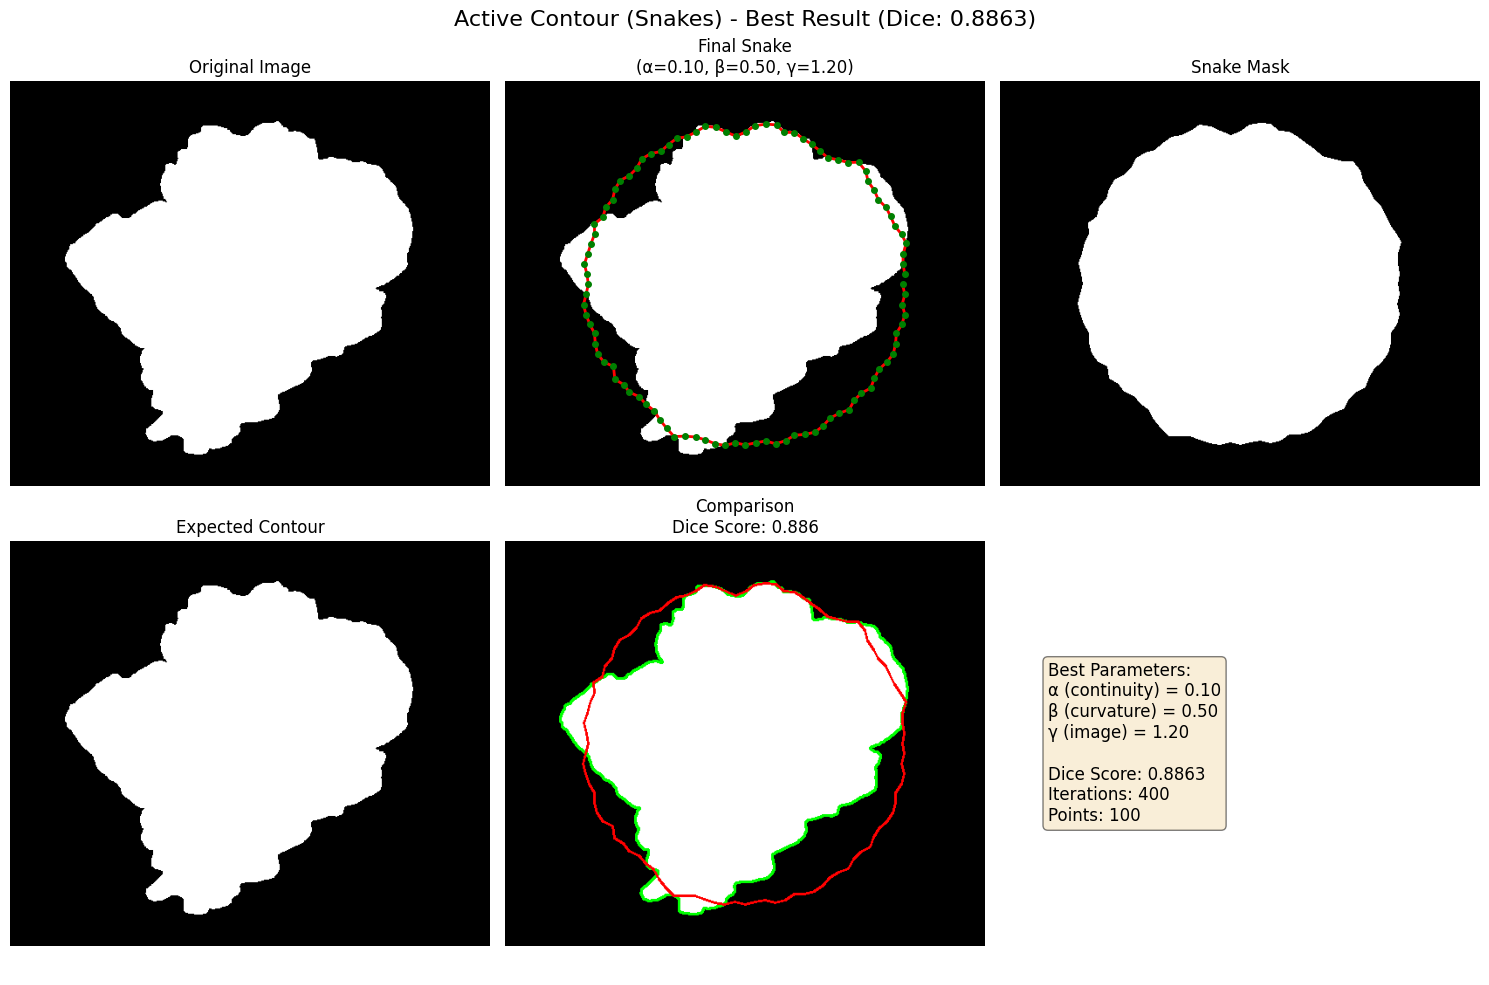


FINAL SUMMARY
Best parameters found:
  Alpha (continuity weight): 0.10
  Beta (curvature weight): 0.50
  Gamma (image energy weight): 1.20

Performance metrics:
  Dice Score: 0.8863
  Iterations: 400
  Number of snake points: 100

All results sorted by Dice score:
------------------------------------------------------------
Rank   Alpha    Beta     Gamma    Dice     Iterations  
------------------------------------------------------------
1      0.10     0.50     1.20     0.8863   400         
2      0.10     0.10     1.20     0.8862   400         
3      0.10     0.30     1.20     0.8862   400         
4      0.10     0.50     0.80     0.8848   400         
5      0.10     0.10     0.80     0.8846   400         
6      0.10     0.30     0.80     0.8839   400         
7      0.30     0.50     1.20     0.8800   400         
8      0.30     0.10     1.20     0.8797   400         
9      0.30     0.30     1.20     0.8797   400         
10     0.30     0.10     0.80     0.8785   400      

In [26]:
def greedy_snake(image, initial_points, M=7, alpha=0.5, beta=0.5, gamma=1.0, 
                 curvature_threshold=0.1, max_iterations=100, min_movement_ratio=0.01):
    """
    Greedy Active Contour (Snakes) algorithm
    
    Parameters:
    -----------
    image : 2D numpy array
        Input grayscale image
    initial_points : Nx2 numpy array
        Initial snake points
    M : int
        Neighborhood size (MxM)
    alpha : float
        Continuity weight
    beta : float
        Curvature weight
    gamma : float
        Image energy weight
    curvature_threshold : float
        Threshold for corner detection
    max_iterations : int
        Maximum number of iterations
    min_movement_ratio : float
        Stop when less than this fraction of points move
    
    Returns:
    --------
    final_points : Nx2 numpy array
        Final snake points
    history : list
        History of snake points for each iteration
    """
    
    # Precompute image energy (inverted gradient magnitude)
    edge_energy = compute_image_energy(image)
    
    # Initialize snake points
    points = initial_points.copy().astype(np.float32)
    n_points = len(points)
    
    # Compute initial average distance between points
    d = np.mean([np.linalg.norm(points[(i+1)%n_points] - points[i]) 
                 for i in range(n_points)])
    
    # Storage for iteration history
    history = [points.copy()]
    
    # Search offset coordinates for MxM neighborhood
    offset = M // 2
    search_offsets = []
    for dx in range(-offset, offset + 1):
        for dy in range(-offset, offset + 1):
            search_offsets.append((dx, dy))
    
    for iteration in range(max_iterations):
        new_points = points.copy()
        moved_count = 0
        
        # Step 1: For each point, search neighborhood for minimum energy
        for i in range(n_points):
            # Get neighboring points indices
            prev_idx = (i-1) % n_points
            next_idx = (i+1) % n_points
            
            prev_point = points[prev_idx]
            next_point = points[next_idx]
            curr_point = points[i]
            
            # Store best position and energy
            best_energy = float('inf')
            best_position = curr_point.copy()
            
            # Search in MxM neighborhood
            for dx, dy in search_offsets:
                candidate = np.array([curr_point[0] + dx, curr_point[1] + dy])
                
                # Ensure candidate is within image bounds
                if (0 <= candidate[0] < image.shape[1] and 
                    0 <= candidate[1] < image.shape[0]):
                    
                    # Compute continuity energy (distance to neighbors)
                    dist_to_prev = np.linalg.norm(candidate - prev_point)
                    dist_to_next = np.linalg.norm(candidate - next_point)
                    
                    # Continuity term: minimize deviation from average distance
                    continuity_energy = alpha * ((dist_to_prev - d)**2 + (dist_to_next - d)**2)
                    
                    # Compute curvature energy (using finite differences)
                    # For candidate position, estimate curvature with neighbors
                    dx1 = candidate[0] - prev_point[0]
                    dy1 = candidate[1] - prev_point[1]
                    dx2 = next_point[0] - candidate[0]
                    dy2 = next_point[1] - candidate[1]
                    
                    # Second derivatives
                    ddx = dx2 - dx1
                    ddy = dy2 - dy1
                    
                    # Curvature magnitude
                    denom = (dx1**2 + dy1**2)**1.5
                    if denom > 0:
                        curvature = np.abs(dx1*ddy - dy1*ddx) / denom
                    else:
                        curvature = 0
                    
                    curvature_energy = beta * curvature**2
                    
                    # Image energy (edge strength - we want low values at edges)
                    # Note: edge_energy is 1-gradient_magnitude, so edges have low values
                    x_int = int(candidate[0])
                    y_int = int(candidate[1])
                    if 0 <= x_int < image.shape[1] and 0 <= y_int < image.shape[0]:
                        image_energy = gamma * edge_energy[y_int, x_int]
                    else:
                        image_energy = float('inf')
                    
                    # Total energy
                    total_energy = continuity_energy + curvature_energy + image_energy
                    
                    if total_energy < best_energy:
                        best_energy = total_energy
                        best_position = candidate
            
            # Update point if it moved
            if not np.array_equal(best_position, curr_point):
                moved_count += 1
                new_points[i] = best_position
        
        # Step 2: Compute curvature and detect corners
        curvatures = compute_curvature(new_points)
        local_maxima = find_local_maxima(curvatures, window=5)
        
        # Set β to zero at corners (curvature local maxima exceeding threshold)
        # In practice, we could adjust weights, but per algorithm description:
        # We simply mark these points as corners
        corners = local_maxima & (curvatures > curvature_threshold)
        
        # Step 3: Update average distance d
        # Compute distances between consecutive points
        distances = []
        for i in range(n_points):
            if not corners[i]:  # Don't include corners in distance calculation
                next_i = (i+1) % n_points
                if not corners[next_i]:  # Also check next point is not a corner
                    dist = np.linalg.norm(new_points[next_i] - new_points[i])
                    distances.append(dist)
        
        if distances:  # Update d if we have valid distances
            d = np.mean(distances)
        
        # Update points
        points = new_points.copy()
        history.append(points.copy())
        
        # Check stopping criterion
        movement_ratio = moved_count / n_points
        if movement_ratio < min_movement_ratio:
            break
        
    return points, history, iteration + 1

def test_parameter_combinations(img_gray, initial_points, expected_mask):
    """Test different parameter combinations and return the best result"""
    
    # Define parameter combinations to test (12 combinations)
    alphas = [0.1, 0.3, 0.5]  # Continuity weight
    betas = [0.1, 0.3, 0.5]   # Curvature weight
    gammas = [0.8, 1.2]       # Image energy weight
    
    # Create all combinations (3*3*2 = 18, we'll take first 12)
    param_combinations = list(itertools.product(alphas, betas, gammas))[:12]
    
    best_dice = -1
    best_params = None
    best_result = None
    results = []
    
    print("Testing 12 parameter combinations:")
    print("-" * 60)
    print(f"{'Alpha':<8} {'Beta':<8} {'Gamma':<8} {'Dice':<8} {'Iterations':<12}")
    print("-" * 60)
    
    for idx, (alpha, beta, gamma) in enumerate(param_combinations):
        # Run snake algorithm with current parameters
        final_points, history, iterations = greedy_snake(
            img_gray, 
            initial_points,
            M=9,
            alpha=alpha,
            beta=beta,
            gamma=gamma,
            curvature_threshold=0.05,
            max_iterations=400,
            min_movement_ratio=0.02
        )
        
        # Create mask from final snake contour
        snake_mask = create_mask_from_contour(final_points, img_gray.shape)
        
        # Compute Dice score
        dice = dice_score(snake_mask > 0, expected_mask > 0)
        
        # Store results
        results.append({
            'alpha': alpha,
            'beta': beta,
            'gamma': gamma,
            'dice': dice,
            'iterations': iterations,
            'final_points': final_points,
            'snake_mask': snake_mask,
            'history': history
        })
        
        # Print current result
        print(f"{alpha:<8.2f} {beta:<8.2f} {gamma:<8.2f} {dice:<8.4f} {iterations:<12}")
        
        # Update best result
        if dice > best_dice:
            best_dice = dice
            best_params = (alpha, beta, gamma)
            best_result = results[-1]
    
    print("-" * 60)
    print(f"Best parameters: alpha={best_params[0]:.2f}, beta={best_params[1]:.2f}, gamma={best_params[2]:.2f}")
    print(f"Best Dice score: {best_dice:.4f}")
    
    return best_result, results

def plot_best_result(img_gray, best_result, expected_mask):
    """Create plot only for the best result"""
    
    final_points = best_result['final_points']
    snake_mask = best_result['snake_mask']
    alpha = best_result['alpha']
    beta = best_result['beta']
    gamma = best_result['gamma']
    dice = best_result['dice']
    
    # Create visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Original image
    axes[0, 0].imshow(img_gray, cmap='gray')
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    # Original image with final snake
    axes[0, 1].imshow(img_gray, cmap='gray')
    axes[0, 1].plot(final_points[:, 0], final_points[:, 1], 'r-', linewidth=2)
    axes[0, 1].plot(final_points[:, 0], final_points[:, 1], 'go', markersize=4)
    axes[0, 1].set_title(f'Final Snake\n(α={alpha:.2f}, β={beta:.2f}, γ={gamma:.2f})')
    axes[0, 1].axis('off')
    
    # Snake mask
    axes[0, 2].imshow(snake_mask, cmap='gray')
    axes[0, 2].set_title('Snake Mask')
    axes[0, 2].axis('off')
    
    # Expected contour
    axes[1, 0].imshow(expected_mask, cmap='gray')
    axes[1, 0].set_title('Expected Contour')
    axes[1, 0].axis('off')
    
    # Overlay comparison
    overlay = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
    # Draw expected contour in green
    contours_expected, _ = cv2.findContours(expected_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours_expected:
        cv2.drawContours(overlay, contours_expected, -1, (0, 255, 0), 2)
    # Draw snake contour in red
    snake_contour = final_points.astype(np.int32).reshape((-1, 1, 2))
    cv2.polylines(overlay, [snake_contour], True, (255, 0, 0), 2)
    axes[1, 1].imshow(overlay)
    axes[1, 1].set_title(f'Comparison\nDice Score: {dice:.3f}')
    axes[1, 1].axis('off')
    
    # Parameter summary and Dice score
    axes[1, 2].axis('off')
    param_text = f"Best Parameters:\n"
    param_text += f"α (continuity) = {alpha:.2f}\n"
    param_text += f"β (curvature) = {beta:.2f}\n"
    param_text += f"γ (image) = {gamma:.2f}\n\n"
    param_text += f"Dice Score: {dice:.4f}\n"
    param_text += f"Iterations: {best_result['iterations']}\n"
    param_text += f"Points: {len(final_points)}"
    
    axes[1, 2].text(0.1, 0.5, param_text, transform=axes[1, 2].transAxes,
                   fontsize=12, verticalalignment='center',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle(f'Active Contour (Snakes) - Best Result (Dice: {dice:.4f})', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return fig

def main():
    # Load images
    image_orig = r'images\skin-waterloo\SSM33_orig.jpg'
    image_orig = r'images\skin-waterloo\SSM33_contour.png'
    
    image_contour = r'images\skin-waterloo\SSM33_contour.png'
    
    # Load the original image
    img_bgr = cv2.imread(image_orig)
    if img_bgr is None:
        # Try without the path prefix if file not found
        image_orig = 'SSM33_orig.jpg'
        img_bgr = cv2.imread(image_orig)
        if img_bgr is None:
            raise FileNotFoundError(f"File not found or cannot be read: {image_orig}")
    
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # Load the expected contour image
    contour_img = cv2.imread(image_contour, cv2.IMREAD_GRAYSCALE)
    if contour_img is None:
        # Try without the path prefix if file not found
        image_contour = 'SSM33_contour.jpg'
        contour_img = cv2.imread(image_contour, cv2.IMREAD_GRAYSCALE)
        if contour_img is None:
            # Create a synthetic contour for testing if no contour image exists
            print("Warning: Contour image not found, creating synthetic contour for testing")
            contour_img = np.zeros_like(img_gray)
            # Create a simple circular contour in the center
            center = (img_gray.shape[1] // 2, img_gray.shape[0] // 2)
            radius = min(img_gray.shape) // 3
            cv2.circle(contour_img, center, radius, 255, -1)
    
    # Create expected mask (threshold if needed)
    if contour_img.max() > 0:
        # Threshold to get binary mask
        _, expected_mask = cv2.threshold(contour_img, 127, 255, cv2.THRESH_BINARY)
    else:
        expected_mask = np.zeros_like(img_gray)
    
    # Initialize snake points (circular contour around center)
    initial_points = initialize_snake_from_image(img_gray.shape, n_points=100)
    
    # Test different parameter combinations
    print("=" * 60)
    print("ACTIVE CONTOUR (SNAKES) PARAMETER OPTIMIZATION")
    print("=" * 60)
    
    best_result, all_results = test_parameter_combinations(img_gray, initial_points, expected_mask)
    
    # Plot only the best result
    print("\n" + "=" * 60)
    print("VISUALIZING BEST RESULT")
    print("=" * 60)
    
    fig = plot_best_result(img_gray, best_result, expected_mask)
    
    # Print detailed summary
    print("\n" + "=" * 60)
    print("FINAL SUMMARY")
    print("=" * 60)
    print(f"Best parameters found:")
    print(f"  Alpha (continuity weight): {best_result['alpha']:.2f}")
    print(f"  Beta (curvature weight): {best_result['beta']:.2f}")
    print(f"  Gamma (image energy weight): {best_result['gamma']:.2f}")
    print(f"\nPerformance metrics:")
    print(f"  Dice Score: {best_result['dice']:.4f}")
    print(f"  Iterations: {best_result['iterations']}")
    print(f"  Number of snake points: {len(best_result['final_points'])}")
    
    # Show all results sorted by Dice score
    print(f"\nAll results sorted by Dice score:")
    print("-" * 60)
    print(f"{'Rank':<6} {'Alpha':<8} {'Beta':<8} {'Gamma':<8} {'Dice':<8} {'Iterations':<12}")
    print("-" * 60)
    
    sorted_results = sorted(all_results, key=lambda x: x['dice'], reverse=True)
    for rank, result in enumerate(sorted_results, 1):
        print(f"{rank:<6} {result['alpha']:<8.2f} {result['beta']:<8.2f} "
              f"{result['gamma']:<8.2f} {result['dice']:<8.4f} {result['iterations']:<12}")
    
    return best_result, all_results


if __name__ == "__main__":
    best_result, all_results = main()

Testing parameter combinations...
--------------------------------------------------------------------------------
Test  1/12: α=0.05, β=0.50, γ=1.00 - Dice: 0.8002, Hausdorff: 95.88
Test  2/12: α=0.05, β=0.80, γ=1.50 - Dice: 0.8002, Hausdorff: 95.88
Test  3/12: α=0.05, β=1.00, γ=2.00 - Dice: 0.8002, Hausdorff: 95.88
Test  4/12: α=0.10, β=0.50, γ=1.50 - Dice: 0.8002, Hausdorff: 95.88
Test  5/12: α=0.10, β=0.80, γ=2.00 - Dice: 0.8002, Hausdorff: 95.88
Test  6/12: α=0.10, β=1.00, γ=2.50 - Dice: 0.8002, Hausdorff: 95.88
Test  7/12: α=0.20, β=0.50, γ=2.00 - Dice: 0.8002, Hausdorff: 95.88
Test  8/12: α=0.20, β=0.80, γ=2.50 - Dice: 0.8002, Hausdorff: 95.88
Test  9/12: α=0.20, β=1.00, γ=3.00 - Dice: 0.8002, Hausdorff: 95.88
Test 10/12: α=0.30, β=0.50, γ=2.50 - Dice: 0.8002, Hausdorff: 95.88
Test 11/12: α=0.30, β=0.80, γ=3.00 - Dice: 0.8002, Hausdorff: 95.88
Test 12/12: α=0.30, β=1.00, γ=3.50 - Dice: 0.8002, Hausdorff: 95.88
---------------------------------------------------------------------

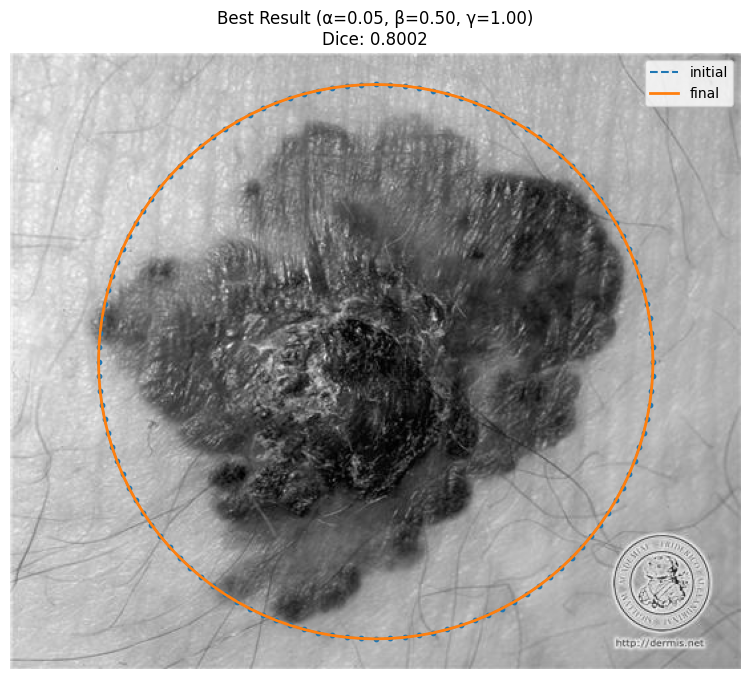

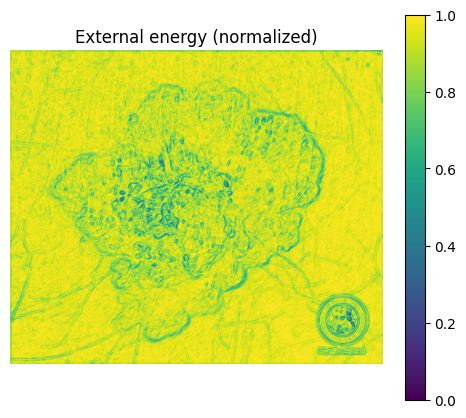

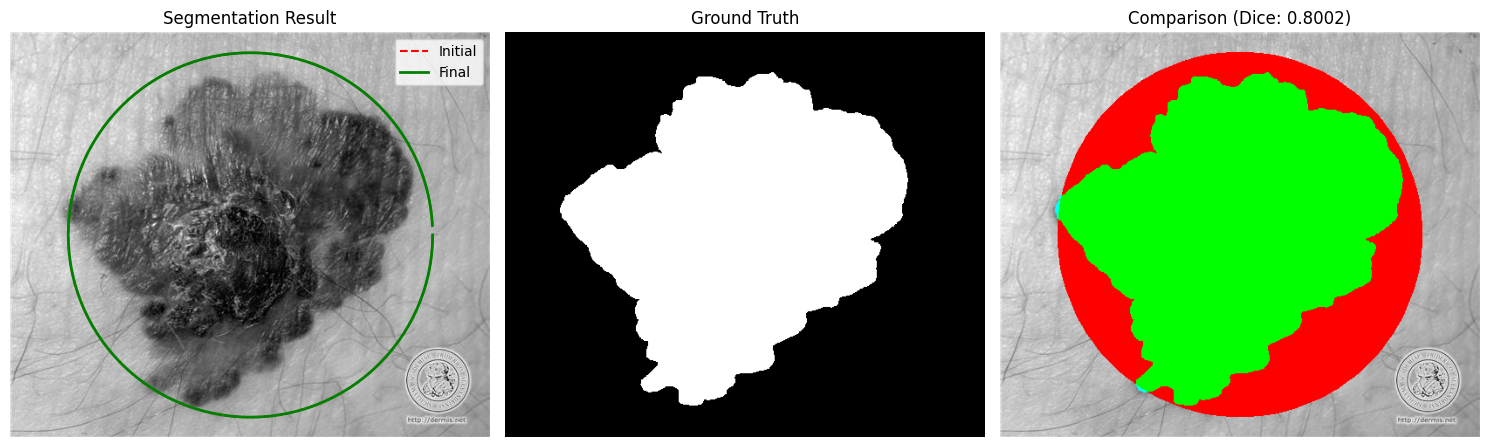

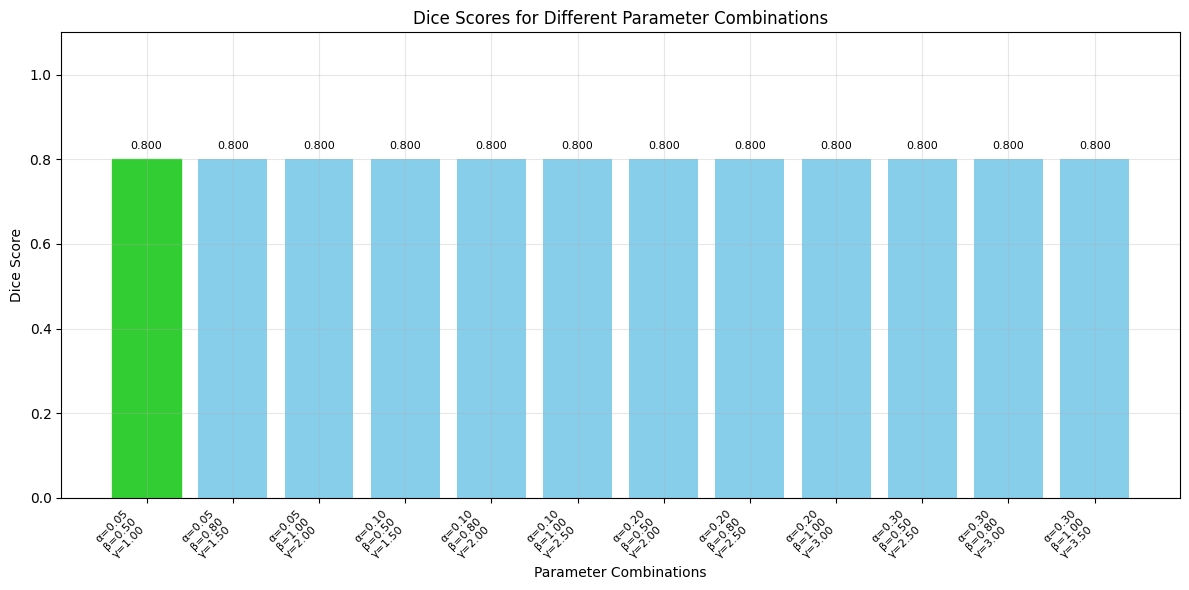

In [6]:
if __name__ == "__main__":
    # image_orig = r'images\synth-images\synthetic.jpg'  # your given path
    # image_orig = r'images\skin-waterloo\SSM33_2_orig.jpg'
    # image_contour = r'images\skin-waterloo\SSM33_2_contour.jpg'
    image_orig = r"C:/Users/ferna/OneDrive/Documentos/Projetos/TPs_Univ/AIP/images/skin-waterloo/SSM33_orig.jpg"
    image_contour = r"C:/Users/ferna/OneDrive/Documentos/Projetos/TPs_Univ/AIP/images/skin-waterloo\SSM33_contour.png"
    
    # Load the original image
    img_bgr = cv2.imread(image_orig)
    if img_bgr is None:
        raise FileNotFoundError(f"File not found or cannot be read: {image_orig}")
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # Load the ground truth contour image
    img_contour_bgr = cv2.imread(image_contour)
    if img_contour_bgr is None:
        raise FileNotFoundError(f"File not found or cannot be read: {image_contour}")
    
    # Convert ground truth contour image to binary mask
    img_contour_gray = cv2.cvtColor(img_contour_bgr, cv2.COLOR_BGR2GRAY)
    _, ground_truth_mask = cv2.threshold(img_contour_gray, 127, 255, cv2.THRESH_BINARY)
    
    # Create an initial circular contour around center
    H, W = img_gray.shape
    center = np.array([W / 2, H / 2], dtype=float)
    R = min(H, W) * 0.45
    Npts = 120
    theta = np.linspace(0, 2 * np.pi, Npts, endpoint=False)
    init_pts = np.column_stack([center[0] + R * np.cos(theta),
                                center[1] + R * np.sin(theta)])

    # Define parameter combinations to test
    param_combinations = [
        # alpha, beta, gamma
        (0.05, 0.5, 1.0),
        (0.05, 0.8, 1.5),
        (0.05, 1.0, 2.0),
        (0.1, 0.5, 1.5),
        (0.1, 0.8, 2.0),  # Original parameters
        (0.1, 1.0, 2.5),
        (0.2, 0.5, 2.0),
        (0.2, 0.8, 2.5),
        (0.2, 1.0, 3.0),
        (0.3, 0.5, 2.5),
        (0.3, 0.8, 3.0),
        (0.3, 1.0, 3.5),
    ]
    
    # Store results
    results = []
    best_dice = -1
    best_params = None
    best_final_pts = None
    best_history = None
    best_E_ext = None
    
    print("Testing parameter combinations...")
    print("-" * 80)
    
    for i, (alpha, beta, gamma) in enumerate(param_combinations, 1):
        print(f"Test {i:2d}/{len(param_combinations)}: α={alpha:.2f}, β={beta:.2f}, γ={gamma:.2f}", end="")
        
        try:
            # Run greedy snake with current parameters
            final_pts, history, E_ext = myfunc.greedy_snake(
                img_gray, init_pts,
                alpha=alpha,
                beta=beta,
                gamma=gamma,
                w_line=0.0,
                w_edge=1.0,
                sigma=1.0,
                M=9,
                max_iter=300,
                move_fraction_tol=0.008,
                #corner_thresh_rel=0.5,
                #shrink_M_if_stable=True,
                verbose=False
            )
            
            # Create mask from final contour
            result_mask = myfunc.create_mask_from_contour(final_pts, img_gray.shape[:2])
            
            # Compute evaluation metrics
            dice = myfunc.dice_score(result_mask > 0, ground_truth_mask > 0)
            hausdorff = myfunc.hausdorff_distance(final_pts, 
                                          cv2.findContours(ground_truth_mask, 
                                                          cv2.RETR_EXTERNAL, 
                                                          cv2.CHAIN_APPROX_SIMPLE)[0][0].reshape(-1, 2))
            
            # Store results
            results.append({
                'alpha': alpha,
                'beta': beta,
                'gamma': gamma,
                'dice': dice,
                'hausdorff': hausdorff,
                'final_pts': final_pts,
                'history': history,
                'E_ext': E_ext
            })
            
            print(f" - Dice: {dice:.4f}, Hausdorff: {hausdorff:.2f}")
            
            # Track best result based on Dice score
            if dice > best_dice:
                best_dice = dice
                best_params = (alpha, beta, gamma)
                best_final_pts = final_pts
                best_history = history
                best_E_ext = E_ext
                
        except Exception as e:
            print(f" - ERROR: {str(e)}")
            results.append({
                'alpha': alpha,
                'beta': beta,
                'gamma': gamma,
                'dice': 0.0,
                'hausdorff': float('inf'),
                'final_pts': None,
                'history': None,
                'E_ext': None
            })
    
    
    print("-" * 80)
    print(f"\nBest parameters: α={best_params[0]:.2f}, β={best_params[1]:.2f}, γ={best_params[2]:.2f}")
    print(f"Best Dice score: {best_dice:.4f}")
    
    # Visualize the best result
    if best_final_pts is not None:
        title = f"Best Result (α={best_params[0]:.2f}, β={best_params[1]:.2f}, γ={best_params[2]:.2f})\nDice: {best_dice:.4f}"
        myfunc.plot_snake(img_gray, init_pts, best_final_pts, E_ext=best_E_ext, title=title)
        
        # Additional visualization: Compare with ground truth
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Original with initial contour
        axes[0].imshow(img_gray, cmap='gray')
        axes[0].plot(init_pts[:, 0], init_pts[:, 1], 'r--', linewidth=1.5, label='Initial')
        axes[0].plot(best_final_pts[:, 0], best_final_pts[:, 1], 'g-', linewidth=2, label='Final')
        axes[0].set_title('Segmentation Result')
        axes[0].legend()
        axes[0].axis('off')
        
        # Ground truth mask
        axes[1].imshow(ground_truth_mask, cmap='gray')
        axes[1].set_title('Ground Truth')
        axes[1].axis('off')
        
        # Overlay comparison
        result_mask = myfunc.create_mask_from_contour(best_final_pts, img_gray.shape[:2])
        overlay = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
        
        # Color coding: Green = TP, Red = FP, Yellow = FN
        result_binary = result_mask > 0
        gt_binary = ground_truth_mask > 0
        
        overlay[result_binary & gt_binary] = [0, 255, 0]  # True positives (green)
        overlay[result_binary & ~gt_binary] = [255, 0, 0]  # False positives (red)
        overlay[~result_binary & gt_binary] = [0, 255, 255]  # False negatives (yellow)
        
        axes[2].imshow(overlay)
        axes[2].set_title(f'Comparison (Dice: {best_dice:.4f})')
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Plot Dice scores for all parameter combinations
        fig, ax = plt.subplots(figsize=(12, 6))
        x_labels = [f"α={r['alpha']:.2f}\nβ={r['beta']:.2f}\nγ={r['gamma']:.2f}" 
                   for r in results]
        dice_values = [r['dice'] for r in results]
        
        bars = ax.bar(range(len(results)), dice_values, color='skyblue')
        
        # Highlight the best result
        best_idx = next(i for i, r in enumerate(results) 
                       if r['alpha'] == best_params[0] and 
                          r['beta'] == best_params[1] and 
                          r['gamma'] == best_params[2])
        bars[best_idx].set_color('limegreen')
        
        ax.set_xlabel('Parameter Combinations')
        ax.set_ylabel('Dice Score')
        ax.set_title('Dice Scores for Different Parameter Combinations')
        ax.set_xticks(range(len(results)))
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1.1])
        
        # Add value labels on top of bars
        for bar, dice in zip(bars, dice_values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{dice:.3f}', ha='center', va='bottom', fontsize=8)
        
        plt.tight_layout()
        plt.show()

Iter   0: Moved 0.933, Avg energy 42.0242
Iter  20: Moved 0.400, Avg energy 18.0394
Iter  40: Moved 0.400, Avg energy 18.0394
Iter  60: Moved 0.400, Avg energy 18.0394
Iter  80: Moved 0.400, Avg energy 18.0394
Iter 100: Moved 0.400, Avg energy 18.0394
Iter 120: Moved 0.400, Avg energy 18.0394
Iter 140: Moved 0.400, Avg energy 18.0394
Iter 160: Moved 0.400, Avg energy 18.0394
Iter 180: Moved 0.400, Avg energy 18.0394
Iter 200: Moved 0.400, Avg energy 18.0394
Iter 220: Moved 0.400, Avg energy 18.0394
Iter 240: Moved 0.400, Avg energy 18.0394
Iter 260: Moved 0.400, Avg energy 18.0394
Iter 280: Moved 0.400, Avg energy 18.0394


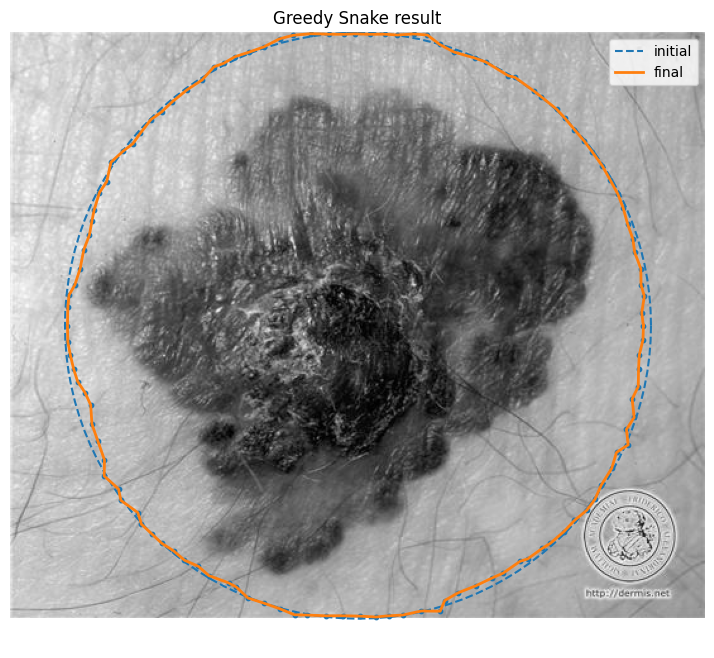

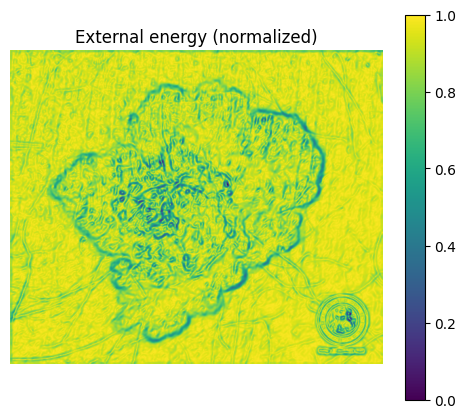

In [12]:
if __name__ == "__main__":
    # image_orig = r'images\synth-images\synthetic.jpg'  # your given path
    image_orig = r'images\skin-waterloo\SSM33_orig.jpg'
    image_contour = r'images\skin-waterloo\SSM33_contour.jpg'
    
    # load the image
    img_bgr = cv2.imread(image_orig)
    if img_bgr is None:
        raise FileNotFoundError(f"File not found or cannot be read: {image_orig}")
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Create an initial circular contour around center (if you don't have one)
    H, W = img_gray.shape
    center = np.array([W / 2, H / 2], dtype=float)
    R = min(H, W) * 0.5
    Npts = 120
    theta = np.linspace(0, 2 * np.pi, Npts, endpoint=False)
    init_pts = np.column_stack([center[0] + R * np.cos(theta),
                                center[1] + R * np.sin(theta)])

    # Run greedy snake
    final_pts, history, E_ext = myfunc.greedy_snake(img_gray, init_pts,
                                             alpha=0.01,
                                             beta=0.05,
                                             gamma=50.0,
                                             w_line=0.0,
                                             w_edge=1.0,
                                             sigma=1.5,
                                             M=11,
                                             max_iter=300,
                                             move_fraction_tol=0.008,
                                             #corner_thresh_rel=0.5,
                                             #shrink_M_if_stable=True,
                                             verbose=True)

    # Plot results
    myfunc.plot_snake(img_gray, init_pts, final_pts, E_ext=E_ext, title="Greedy Snake result")

